# 환경준비

In [9]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# %pip install transformers sentencepiece tokenizers pandas matplotlib
# %pip install pytorch

  Using cached pytorch-1.0.2.tar.gz (689 bytes)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pytorch


  error: subprocess-exited-with-error
  
  × Building wheel for pytorch (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [37 lines of output]
      Traceback (most recent call last):
        File "c:\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "c:\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 280, in build_wheel
          return _build_backend().build_wheel(
                 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
              wheel_directory, config_settings, metadata_directory
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
          )
          ^
        File "C

In [1]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer
#`from transformers import AutoTokenizer`는 Hugging Face의 `transformers` 라이브러리에서 `AutoTokenizer` 클래스를 불러오는 코드입니다.
##즉, 이 한 줄은 텍스트를 모델이 이해할 수 있는 토큰(token) 형태로 변환하기 위한 도구를 가져오는 것입니다.
### transformers: 자연어처리(NLP), LLM, 번역, 요약, 분류 등 다양한 사전학습 모델을 제공하는 파이썬 라이브러리
### AutoTokenizer: 모델 이름에 맞는 적절한 토크나이저(tokenizer)를 자동으로 선택해서 불러오는 클래스

c:\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 실습용 문장 준비

In [2]:
sentences = [
    "토큰화는 자연어처리의 시작입니다.",
    "LLM models process text as tokens, not words.",
    "오늘은 tokenization과 vocabulary를 함께 배웁니다.",
    "ChatGPT는 문장을 내부적으로 토큰 단위로 처리합니다.",
    "한국어와 English가 섞인 문장은 토큰화 결과가 달라질 수 있습니다."
]

for i, s in enumerate(sentences, 1):
    print(f"{i}. {s}")

1. 토큰화는 자연어처리의 시작입니다.
2. LLM models process text as tokens, not words.
3. 오늘은 tokenization과 vocabulary를 함께 배웁니다.
4. ChatGPT는 문장을 내부적으로 토큰 단위로 처리합니다.
5. 한국어와 English가 섞인 문장은 토큰화 결과가 달라질 수 있습니다.


## 문자 단위 토큰화

가장 단순한 방식으로 해보자.

In [3]:
## 내장 함수 사용하지 않고 하는 방법
# 코테 연습에 많이 도움됨
def char_tokenize(text):
    result = []
    i=0

    while True:
        try:
            ch = text[i]
            result += [ch]
            i +=1
        except IndexError:
            break
    return result

In [ ]:
def char_tokenize(text):
    return list(text)
# list로 선언했는데 왜 한글자씩 잘릴까?
# list는 반복 가능한 객체 (iterable)
example = sentences[2]
char_tokens = char_tokenize(example)

print("원문:", example)
print("문자 토큰:", char_tokens)
print("문자 수:", len(char_tokens))

원문: 오늘은 tokenization과 vocabulary를 함께 배웁니다.
문자 토큰: ['오', '늘', '은', ' ', 't', 'o', 'k', 'e', 'n', 'i', 'z', 'a', 't', 'i', 'o', 'n', '과', ' ', 'v', 'o', 'c', 'a', 'b', 'u', 'l', 'a', 'r', 'y', '를', ' ', '함', '께', ' ', '배', '웁', '니', '다', '.']
문자 수: 38
s


단어 단위 토큰화 / 공백 기준

In [7]:
def word_tokenize_simple(text):
    return text.split()

word_tokens = word_tokenize_simple(example)

print("원문:", example)
print("단어 토큰:", word_tokens)
print("단어 수:", len(word_tokens))

원문: 오늘은 tokenization과 vocabulary를 함께 배웁니다.
단어 토큰: ['오늘은', 'tokenization과', 'vocabulary를', '함께', '배웁니다.']
단어 수: 5


- 문자 단위는 너무 잘게 쪼개져서 길이가 길어짐.
- 단어 단위는 간단하지만,
    - 'tokenization과' 같은 혼합 표현 처리에 약하고
    - 조사, 어미, 특수문자 처리에 한계가 있음.

## 서브워드 토크나이저 비교

실제 LLM/NLP에서 많이 쓰는 토크나이저를 비교합니다.

- BPE 계열: GPT-2

- WordPiece 계열: BERT

- SentencePiece 계열: XLM-Roberta

In [8]:
from transformers import AutoTokenizer

# [BPE 예시]
# GPT-2는 BPE(Byte Pair Encoding) 기반 토크나이저를 사용한다.
# 이번 실습에서는 "대표적인 BPE 방식"을 보여주기 위한 예시로 사용한다.
# 꼭 GPT-2 자체를 학습에 쓰려는 것이 아니라, BPE의 분해 원리를 관찰하는 목적이다.
bpe_tokenizer = AutoTokenizer.from_pretrained("gpt2")

# [WordPiece 예시]
# BERT는 WordPiece 기반 토크나이저를 사용한다.
# WordPiece는 자주 쓰이는 서브워드를 사전에 포함하고,
# 희귀 단어는 여러 조각으로 분해하여 처리하는 대표적인 방식이다.
wordpiece_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# [SentencePiece 예시]
# XLM-Roberta는 SentencePiece 기반 토크나이저를 사용한다.
# SentencePiece는 공백까지 포함하여 처리할 수 있고,
# 다국어 환경에서 널리 사용되는 대표적인 서브워드 방식이다.
sp_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

같은 문장을 여러 토크나이저로 분해해보기

In [9]:
def inspect_tokenization(text, tokenizer, name):
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.convert_tokens_to_ids(tokens)

    print(f"\n[{name}]")
    print("원문:", text)
    print("토큰:", tokens)
    print("토큰 수:", len(tokens))
    print("토큰 ID:", ids)

example = "오늘은 tokenization과 vocabulary를 함께 배웁니다."

inspect_tokenization(example, bpe_tokenizer, "BPE (GPT-2)")
inspect_tokenization(example, wordpiece_tokenizer, "WordPiece (BERT)")
inspect_tokenization(example, sp_tokenizer, "SentencePiece (XLM-R)")


[BPE (GPT-2)]
원문: 오늘은 tokenization과 vocabulary를 함께 배웁니다.
토큰: ['ì', 'ĺ', '¤', 'ë', 'Ĭ', 'ĺ', 'ìĿ', 'Ģ', 'Ġtoken', 'ization', 'ê', '³', '¼', 'Ġvocabulary', 'ë', '¥', '¼', 'Ġ', 'íķ', '¨', 'ê', '»', 'ĺ', 'Ġë', '°', '°', 'ì', 'Ľ', 'ģ', 'ëĭ', 'Ī', 'ëĭ', '¤', '.']
토큰 수: 34
토큰 ID: [168, 246, 97, 167, 232, 246, 35975, 222, 11241, 1634, 166, 111, 120, 25818, 167, 98, 120, 220, 47991, 101, 166, 119, 246, 31619, 108, 108, 168, 249, 223, 46695, 230, 46695, 97, 13]

[WordPiece (BERT)]
원문: 오늘은 tokenization과 vocabulary를 함께 배웁니다.
토큰: ['ᄋ', '##ᅩ', '##ᄂ', '##ᅳ', '##ᆯ', '##ᄋ', '##ᅳ', '##ᆫ', 'token', '##ization', '##ᄀ', '##ᅪ', 'vocabulary', '##ᄅ', '##ᅳ', '##ᆯ', '[UNK]', 'ᄇ', '##ᅢ', '##ᄋ', '##ᅮ', '##ᆸ', '##ᄂ', '##ᅵ', '##ᄃ', '##ᅡ', '.']
토큰 수: 27
토큰 ID: [1463, 30011, 29992, 30017, 30022, 29999, 30017, 30021, 19204, 3989, 29991, 30012, 16188, 29994, 30017, 30022, 100, 1460, 30007, 29999, 30014, 30024, 29992, 30019, 29993, 30006, 1012]

[SentencePiece (XLM-R)]
원문: 오늘은 tokenization과 vocabulary를 함께 배웁니다.
토큰: ['▁

여러 문장을 표로 정리

In [18]:
import pandas as pd
rows = []

for text in sentences:
    bpe_tokens = bpe_tokenizer.tokenize(text)
    wp_tokens = wordpiece_tokenizer.tokenize(text)
    sp_tokens = sp_tokenizer.tokenize(text)
    
    rows.append({
        "sentence": text,
        "BPE_token_count": len(bpe_tokens),
        "WordPiece_token_count": len(wp_tokens),
        "SentencePiece_token_count": len(sp_tokens),
        "BPE_tokens": str(bpe_tokens),
        "WordPiece_tokens": str(wp_tokens),
        "SentencePiece_tokens": str(sp_tokens),
    })

df_compare = pd.DataFrame(rows)
df_compare

,sentence,BPE_token_count,WordPiece_token_count,SentencePiece_token_count,BPE_tokens,WordPiece_tokens,SentencePiece_tokens
0,토큰화는 자연어처리의 시작입니다.,43,36,11,"['í', 'Ĩ', 'ł', 'í', 'ģ', '°', 'í', 'Ļ', 'Ķ', ...","['ᄐ', '##ᅩ', '##ᄏ', '##ᅳ', '##ᆫ', '##ᄒ', '##ᅪ'...","['▁토', '큰', '화', '는', '▁자연', '어', '처리', '의', '..."
1,"LLM models process text as tokens, not words.",11,12,12,"['LL', 'M', 'Ġmodels', 'Ġprocess', 'Ġtext', 'Ġ...","['ll', '##m', 'models', 'process', 'text', 'as...","['▁L', 'LM', '▁models', '▁process', '▁text', '..."
2,오늘은 tokenization과 vocabulary를 함께 배웁니다.,34,27,13,"['ì', 'ĺ', '¤', 'ë', 'Ĭ', 'ĺ', 'ìĿ', 'Ģ', 'Ġto...","['ᄋ', '##ᅩ', '##ᄂ', '##ᅳ', '##ᆯ', '##ᄋ', '##ᅳ'...","['▁오늘은', '▁to', 'ken', 'ization', '과', '▁vocab..."
3,ChatGPT는 문장을 내부적으로 토큰 단위로 처리합니다.,58,44,15,"['Chat', 'G', 'PT', 'ë', 'Ĭ', 'Ķ', 'Ġë', '¬', ...","['chat', '##gp', '##t', '##ᄂ', '##ᅳ', '##ᆫ', '...","['▁Chat', 'G', 'PT', '는', '▁문', '장을', '▁내부', '..."
4,한국어와 English가 섞인 문장은 토큰화 결과가 달라질 수 있습니다.,71,49,19,"['íķ', 'ľ', 'ê', 'µ', 'Ń', 'ì', 'ĸ', '´', 'ì',...","['ᄒ', '##ᅡ', '##ᆫ', '##ᄀ', '##ᅮ', '##ᆨ', '##ᄋ'...","['▁한국어', '와', '▁English', '가', '▁', '섞', '인', ..."


Corpus 전체 평균 토큰 길이 측정

전체 corpus에서 평균적으로 몇 개의 토큰이 나오는지

In [19]:
def corpus_token_stats(texts, tokenizer, name):
    token_counts = [len(tokenizer.tokenize(t)) for t in texts]
    stats = {
        "tokenizer": name,
        "num_sentences": len(texts),
        "avg_tokens": sum(token_counts) / len(token_counts),
        "min_tokens": min(token_counts),
        "max_tokens": max(token_counts),
        "total_tokens": sum(token_counts)
    }
    return stats

stats_list = []
stats_list.append(corpus_token_stats(sentences, bpe_tokenizer, "BPE (GPT-2)"))
stats_list.append(corpus_token_stats(sentences, wordpiece_tokenizer, "WordPiece (BERT)"))
stats_list.append(corpus_token_stats(sentences, sp_tokenizer, "SentencePiece (XLM-R)"))

df_stats = pd.DataFrame(stats_list)
df_stats

,tokenizer,num_sentences,avg_tokens,min_tokens,max_tokens,total_tokens
0,BPE (GPT-2),5,43.4,11,71,217
1,WordPiece (BERT),5,33.6,12,49,168
2,SentencePiece (XLM-R),5,14.0,11,19,70


시각화

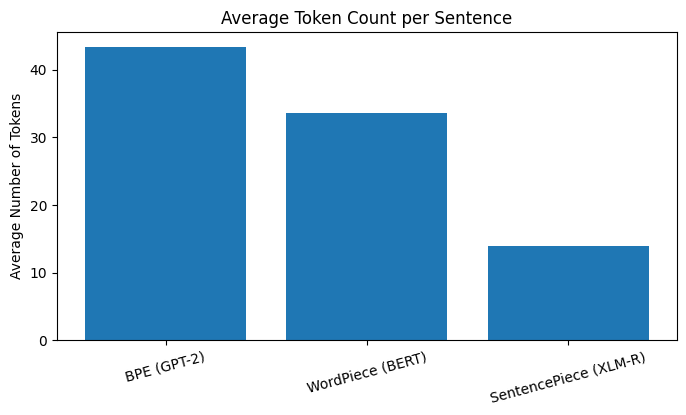

In [20]:
plt.figure(figsize=(8,4))
plt.bar(df_stats["tokenizer"], df_stats["avg_tokens"])
plt.title("Average Token Count per Sentence")
plt.ylabel("Average Number of Tokens")
plt.xticks(rotation=15)
plt.show()

- 평균 토큰 수가 많을수록 같은 문장도 더 길게 처리됩니다.

- 토큰 수가 많아지면 일반적으로:

    - 입력 비용 증가

    - context window 더 빨리 소모

    - 추론 속도 부담 증가

In [12]:
sample_text = "한국어와 English가 섞인 문장은 토큰화 결과가 달라질 수 있습니다."

for name, tokenizer in [
    ("BPE", bpe_tokenizer),
    ("WordPiece", wordpiece_tokenizer),
    ("SentencePiece", sp_tokenizer)
]:
    n_tokens = len(tokenizer.tokenize(sample_text))
    print(f"{name}: {n_tokens} tokens")

BPE: 71 tokens
WordPiece: 49 tokens
SentencePiece: 19 tokens


- 같은 문장이라도 토크나이저에 따라 토큰 수가 달라짐

Q. 한국어와 영어가 섞인 문장은 토큰화 결과가 달라질 수 있다는건 같은 문장에 같은 토크나이저여도 영어와 한글이 섞여있으면 결과가 매번 다를 수 있다는건가요? 그럴 수 있다.

- API 과금이 토큰 기준이면 비용도 달라질 수 있음

- context window가 8k, 32k, 128k라 해도 실제 사용 가능한 문장 수는 토큰화 방식에 영향받음

### 어휘 사전(vocab) 구성 원리

직접 작은 corpus을 가지고 vocab size를 달리하며 토큰화가 어떻게 달라지는지를 살펴보자.

여기서는 Hugging Face tokenizer 라이브러리로 BPE 토크나이저를 직접 학습합니다.

In [21]:
# 실습용 작은 Corpus 만들기
corpus = [
    "토큰화는 자연어처리의 시작입니다.",
    "토큰은 모델이 텍스트를 이해하는 기본 단위입니다.",
    "서브워드 방식은 희귀 단어를 더 잘 처리할 수 있습니다.",
    "vocabulary 크기가 커지면 더 긴 조각을 한 번에 표현할 수 있습니다.",
    "한국어와 영어가 섞인 문장은 분해 방식이 달라질 수 있습니다.",
    "LLM은 입력 문장을 토큰 시퀀스로 변환하여 처리합니다.",
    "BPE는 자주 등장하는 문자 조합을 병합합니다.",
    "WordPiece는 확률적 관점이 반영된 방식으로 설명되기도 합니다.",
    "SentencePiece는 공백이 없는 언어에도 적용하기 좋습니다.",
    "OOV 문제를 줄이기 위해 서브워드 토큰화가 널리 사용됩니다."
]

with open("toy_corpus.txt", "w", encoding="utf-8") as f:
    for line in corpus:
        f.write(line + "\n")

In [22]:
# vocab size를 바꿔가며 BPE 토크나이저 학습
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer

def train_bpe_tokenizer(vocab_size, files):
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"]
    )
    tokenizer.train(files, trainer)
    return tokenizer

bpe_100 = train_bpe_tokenizer(100, ["toy_corpus.txt"])
bpe_200 = train_bpe_tokenizer(200, ["toy_corpus.txt"])
bpe_300 = train_bpe_tokenizer(300, ["toy_corpus.txt"])

In [23]:
# 같은 문장을 vocab size별로 비교
test_sentence = "서브워드 토큰화는 희귀 단어 처리에 유리합니다."

for vocab_size, tok in [(100, bpe_100), (200, bpe_200), (300, bpe_300)]:
    output = tok.encode(test_sentence)
    print(f"\n[vocab_size={vocab_size}]")
    print("토큰:", output.tokens)
    print("토큰 수:", len(output.tokens))


[vocab_size=100]
토큰: ['서', '브', '워', '드', '토', '큰', '화', '는', '희', '귀', '단', '어', '처', '리', '에', '[UNK]', '리', '합', '니', '다', '.']
토큰 수: 21

[vocab_size=200]
토큰: ['서브워드', '토큰화', '는', '희', '귀', '단어', '처리', '에', '[UNK]', '리', '합니다', '.']
토큰 수: 12

[vocab_size=300]
토큰: ['서브워드', '토큰화는', '희귀', '단어', '처리', '에', '[UNK]', '리', '합니다', '.']
토큰 수: 10


- vocab size가 작으면 문장이 더 잘게 쪼개짐

- vocab size가 크면 더 긴 조각이 vocab에 들어가므로 토큰 수가 줄 수 있음

    - 하지만 vocab이 너무 크면

    - 메모리 부담 증가

    - 학습 효율과 일반화 측면에서 trade-off 발생 가능

In [24]:
# vocab size별 평균 토큰 길이 비교
def avg_token_count_custom(tokenizer, texts):
    counts = [len(tokenizer.encode(t).tokens) for t in texts]
    return sum(counts) / len(counts)

vocab_results = []
for vocab_size, tok in [(100, bpe_100), (200, bpe_200), (300, bpe_300)]:
    vocab_results.append({
        "vocab_size": vocab_size,
        "avg_tokens": avg_token_count_custom(tok, corpus)
    })

df_vocab = pd.DataFrame(vocab_results)
df_vocab


,vocab_size,avg_tokens
0,100,25.7
1,200,15.0
2,300,8.2


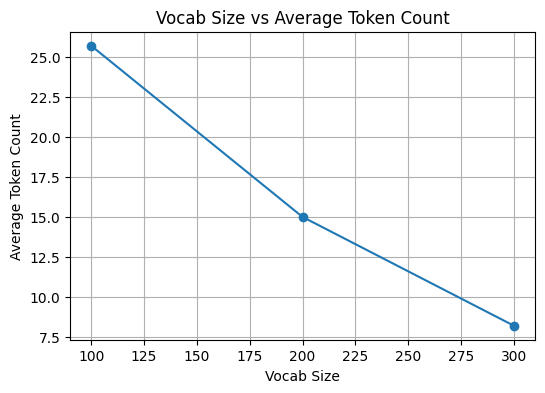

In [25]:
plt.figure(figsize=(6,4))
plt.plot(df_vocab["vocab_size"], df_vocab["avg_tokens"], marker="o")
plt.title("Vocab Size vs Average Token Count")
plt.xlabel("Vocab Size")
plt.ylabel("Average Token Count")
plt.grid(True)
plt.show()

## OOV 문제 관찰

서브워드 토큰화의 중요한 장점은 처음 보는 단어도 완전히 깨지지 않고 부분 조합으로 처리 가능

In [19]:
oov_text = "초거대멀티모달토크나이저"

for vocab_size, tok in [(100, bpe_100), (200, bpe_200), (300, bpe_300)]:
    output = tok.encode(oov_text)
    print(f"\n[vocab_size={vocab_size}]")
    print(output.tokens)
    print("토큰 수:", len(output.tokens))


[vocab_size=100]
['[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '모', '달', '토', '크', '[UNK]', '이', '[UNK]']
토큰 수: 12

[vocab_size=200]
['[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '모', '달', '토', '크', '[UNK]', '이', '[UNK]']
토큰 수: 12

[vocab_size=300]
['[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '모', '달', '토', '크', '[UNK]', '이', '[UNK]']
토큰 수: 12


- 단어 단위 토큰화에서는 새로운 단어가 나오면 OOV가 쉽게 발생

- 서브워드 방식에서는 낯선 단어도 부분 조각으로 나누어 처리 가능

- 이것이 LLM에서 서브워드 토큰화가 널리 쓰이는 핵심 이유 중 하나

## 한국어 / 영어 / 혼합 데이터 토큰화 이슈

In [26]:
samples = [
    "나는 오늘 학교에 갔다.",
    "I went to school today.",
    "나는 today 학교에 갔다."
]

for text in samples:
    print("\n==========================")
    print("문장:", text)
    print("BPE:", bpe_tokenizer.tokenize(text))
    print("WordPiece:", wordpiece_tokenizer.tokenize(text))
    print("SentencePiece:", sp_tokenizer.tokenize(text))


문장: 나는 오늘 학교에 갔다.
BPE: ['ë', 'Ĥ', 'ĺ', 'ë', 'Ĭ', 'Ķ', 'Ġì', 'ĺ', '¤', 'ë', 'Ĭ', 'ĺ', 'Ġ', 'íķ', 'Ļ', 'ê', 'µ', 'Ĳ', 'ì', 'Ĺ', 'Ĳ', 'Ġ', 'ê', '°', 'Ķ', 'ëĭ', '¤', '.']
WordPiece: ['ᄂ', '##ᅡ', '##ᄂ', '##ᅳ', '##ᆫ', 'ᄋ', '##ᅩ', '##ᄂ', '##ᅳ', '##ᆯ', 'ᄒ', '##ᅡ', '##ᆨ', '##ᄀ', '##ᅭ', '##ᄋ', '##ᅦ', '[UNK]', '.']
SentencePiece: ['▁나는', '▁오늘', '▁학교', '에', '▁', '갔다', '.']

문장: I went to school today.
BPE: ['I', 'Ġwent', 'Ġto', 'Ġschool', 'Ġtoday', '.']
WordPiece: ['i', 'went', 'to', 'school', 'today', '.']
SentencePiece: ['▁I', '▁went', '▁to', '▁school', '▁today', '.']

문장: 나는 today 학교에 갔다.
BPE: ['ë', 'Ĥ', 'ĺ', 'ë', 'Ĭ', 'Ķ', 'Ġtoday', 'Ġ', 'íķ', 'Ļ', 'ê', 'µ', 'Ĳ', 'ì', 'Ĺ', 'Ĳ', 'Ġ', 'ê', '°', 'Ķ', 'ëĭ', '¤', '.']
WordPiece: ['ᄂ', '##ᅡ', '##ᄂ', '##ᅳ', '##ᆫ', 'today', 'ᄒ', '##ᅡ', '##ᆨ', '##ᄀ', '##ᅭ', '##ᄋ', '##ᅦ', '[UNK]', '.']
SentencePiece: ['▁나는', '▁today', '▁학교', '에', '▁', '갔다', '.']


In [21]:
#토크나이저 비교표
summary_rows = []

for text in sentences:
    summary_rows.append({
        "문장": text,
        "BPE 토큰 수": len(bpe_tokenizer.tokenize(text)),
        "WordPiece 토큰 수": len(wordpiece_tokenizer.tokenize(text)),
        "SentencePiece 토큰 수": len(sp_tokenizer.tokenize(text))
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,문장,BPE 토큰 수,WordPiece 토큰 수,SentencePiece 토큰 수
0,토큰화는 자연어처리의 시작입니다.,43,36,11
1,"LLM models process text as tokens, not words.",11,12,12
2,오늘은 tokenization과 vocabulary를 함께 배웁니다.,34,27,13
3,ChatGPT는 문장을 내부적으로 토큰 단위로 처리합니다.,58,44,15
4,한국어와 English가 섞인 문장은 토큰화 결과가 달라질 수 있습니다.,71,49,19


In [ ]:
#df_summary.to_csv("tokenizer_comparison.csv", index=False, encoding="utf-8-sig")

In [22]:
# 토큰 수 분석 결과
df_stats.to_csv("token_count_analysis.csv", index=False, encoding="utf-8-sig")
df_vocab.to_csv("vocab_size_analysis.csv", index=False, encoding="utf-8-sig")

tiktoken 라이브러리로 접했던 것 같은데 이것도 많이 활용되나요?

- 네 많이 사용됩니다. 특히 OpenAI 계열 모델을 다룰 때에는 실무에서 자주 쓰임.
- OpenAI 모델용 빠른 BPE 토크나이저입니다.

In [1]:
# %pip install tiktoken
import tiktoken

#예시 문장
text = "Hello, how are you today? 안녕하세요. 오늘 기분이 어떠신가요?"

#사용할 모델에 맞는 토크나이저를 선택
enc = tiktoken.encoding_for_model('gpt-4o')

# 텍스트를 토큰으로 변환
tokens = enc.encode(text)

print('원문: ')
print(text)

print('\n토큰 ID: ')
print(tokens)

print('\n토큰 개수: ')
print(len(tokens))

원문: 
Hello, how are you today? 안녕하세요. 오늘 기분이 어떠신가요?

토큰 ID: 
[13225, 11, 1495, 553, 481, 4044, 30, 24497, 171731, 13, 106820, 11061, 15567, 2186, 51190, 254, 11753, 4081, 7952, 30]

토큰 개수: 
20


긴 문장 실습

In [10]:
# 긴 문장
import tiktoken

text = """
자연어처리는 사람이 사용하는 언어를 컴퓨터가 이해하고 처리할 수 있도록 만드는 분야입니다.
최근에는 대규모 언어 모델이 발전하면서 번역, 요약, 질의응답, 정보추출 등의 성능이 크게 향상되었습니다.
하지만 입력 길이 제한이 있기 때문에 긴 문서는 적절한 단위로 나누어 처리해야 합니다.
"""

enc = tiktoken.encoding_for_model("gpt-4o")
tokens = enc.encode(text)

#chunk 단위로 자르기
chunk_size = 20 # 20토큰씩 자르기.
chunks = []

for i in range(0, len(tokens), chunk_size):
    chunk_toknes = tokens[i:i+chunk_size]
    chunk_text = enc.decode(chunk_toknes)
    chunks.append(chunk_text)
print("전체 토큰 수:", len(tokens))
print()

for idx, chunk in enumerate(chunks, start=1):
    print(f"청크{idx}")
    print(chunk)
    print("-"*30)

전체 토큰 수: 82

청크1

자연어처리는 사람이 사용하는 언어를 컴퓨터가 이해하고 처리할 수 있도록
------------------------------
청크2
 만드는 분야입니다.
최근에는 대규모 언어 모델이 발전하면서 번역, 요약
------------------------------
청크3
, 질의응답, 정보추출 등의 성능이 크게 향상되었습니다.
하지만 입력
------------------------------
청크4
 길이 제한이 있기 때문에 긴 문서는 적절한 단위로 나누어 처리해야
------------------------------
청크5
 합니다.

------------------------------
